# Infos.json

In [41]:
import json
from PIL import Image
import numpy as np 

In [ ]:
p = "/home/zchen/Code/NeUF_new/data/simu_56/us/us0.jpg"
# p = "/home/zchen/Code/NeUF_new/data/bluephantom/sync/export/us/us0.jpg"
im = Image.open(p).convert('L')
# resize so the largest side is 150 pixels (scales up or down)
w, h = im.size
target = 150
scale = target / max(w, h)
new_w = max(1, int(round(w * scale)))
new_h = max(1, int(round(h * scale)))
im = im.resize((new_w, new_h), Image.LANCZOS)
px_shape = np.array(im).shape
px_shape

(1632, 2447)

In [43]:
with open("/home/zchen/Code/NeUF_new/data/simu_56/infos.dat", "r") as f:
    lines = f.readlines()

In [ ]:
import re
pattern = r'[+-]?\d+\.\d+'
matches = re.findall(pattern, lines[0])
dimensions = [float(x) for x in matches]

[0.0, 0.0, 19.544413]

In [46]:
width = lines[1].strip().split(" ")[-2]
depth = lines[1].strip().split(" ")[-1]

In [47]:
infos_dict = {}
infos_dict['infos'] = {
    "bounding_box_3D": {
        "point_min": dimensions[:3],
        "point_max": dimensions[3:6],
        "size": dimensions[6:9]
    },
    "scan_dims_mm": {
        "width": width,
        "depth": depth
    },
    "scan_dims_px": {
        "width": px_shape[1],
        "height": px_shape[0]
    },
}

In [48]:
for i in range(1, len(lines) - 1):

    lines[i + 1].strip().split(" ")
    infos_dict[f'{i}'] = {
        "x": lines[i + 1].strip().split(" ")[0],
        "y": lines[i + 1].strip().split(" ")[1],
        "z": lines[i + 1].strip().split(" ")[2],
        "w0": lines[i + 1].strip().split(" ")[3],
        "w1": lines[i + 1].strip().split(" ")[4],
        "w2": lines[i + 1].strip().split(" ")[5],
        "w3": lines[i + 1].strip().split(" ")[6],
    }

In [52]:
with open("/home/zchen/Code/NeUF_new/data/simu_56/infos.json", "w") as f:
    json.dump(infos_dict, f, indent=4)

# US Image

In [1]:
from PIL import Image
import numpy as np
import os


In [27]:
imgs_path = "/home/zchen/Code/NeUF_new/data/simu_56/us"
imgs_path_new = "/home/zchen/Code/NeUF_new/data/simu_56/us_resized"
os.makedirs(imgs_path_new, exist_ok=True)
imgs_p = sorted(os.listdir(imgs_path), key=lambda x: int(x.split('us')[1].split('.jpg')[0]))
for i in range(len(imgs_p)):
    im = Image.open(os.path.join(imgs_path, imgs_p[i])).convert('L')
    im.thumbnail((150, 150), Image.LANCZOS)
    im.save(os.path.join(imgs_path_new, imgs_p[i]))

In [4]:
imgs_path = "D:\\0-Code\\NeUF\\data\\simu_56\\us"
Image.open(f"{imgs_path}\\us0.jpg").convert('L').size

(150, 100)

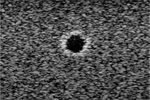

In [ ]:
import shutil

old_dir = "/home/zchen/Code/NeUF_new/data/simu_56/us"
new_dir = "/home/zchen/Code/NeUF_new/data/simu_56/us_0"
os.rename(old_dir, new_dir)

# Get resized US image

In [ ]:
import torch

torch.load("/home/zchen/Code/NeUF_new/logs/simu_56_neuf/checkpoints/best_model.pth")

In [2]:
from PIL import Image
import numpy as np
im = Image.open("D:\\0-Code\\NeUF\\data\\bluephantom\\sync\\export\\us\\us0.jpg").convert('L')
np.array(im).shape

(173, 143)

In [ ]:
from PIL import Image
import numpy as np
im = Image.open("D:\\0-Code\\NeUF\\data\\cerebral_data\\Pre_traitement_echo_v2\\Recalage\\Patient0\\us_recal_original\\us0.jpg").convert('L')
np.array(im).shape

## GT image

In [2]:
import torch
import matplotlib.pyplot as plt

# Process all A1, B1, C1, D1 ground truth files
base_path = r"logs\27-02-2026\HASH_Patient0_0\images"
slice_names = ['A1', 'B1', 'C1', 'D1']

for name in slice_names:
    # Load the .pt file
    gt_tensor = torch.load(f"{base_path}\\{name}_gt.pt")
    
    # Convert to numpy and save as PNG
    output_path = f"{base_path}\\{name}_gt_converted.png"
    plt.imsave(output_path, gt_tensor.cpu().numpy(), cmap='gray')
    
    print(f"Saved {name}: {output_path}")
    print(f"  Tensor shape: {gt_tensor.shape}")

print("\nAll ground truth images converted to PNG!")

Saved A1: logs\27-02-2026\HASH_Patient0_0\images\A1_gt_converted.png
  Tensor shape: torch.Size([290, 212])
Saved B1: logs\27-02-2026\HASH_Patient0_0\images\B1_gt_converted.png
  Tensor shape: torch.Size([290, 212])
Saved C1: logs\27-02-2026\HASH_Patient0_0\images\C1_gt_converted.png
  Tensor shape: torch.Size([290, 212])
Saved D1: logs\27-02-2026\HASH_Patient0_0\images\D1_gt_converted.png
  Tensor shape: torch.Size([290, 212])

All ground truth images converted to PNG!


# Evaluation

## PSNR MSE

In [25]:
import torch
import numpy as np
from pathlib import Path
from nerf_network import NeRF
from dataset_1 import Dataset
from slice_renderer import SliceRenderer

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load checkpoint
checkpoint_path = r"logs\27-02-2026\HASH_Patient0_0\checkpoints\5000.pkl"
ckpt = torch.load(checkpoint_path, map_location=device)

print(f"Loaded checkpoint from: {checkpoint_path}")
print(f"Checkpoint keys: {list(ckpt.keys())}")

# Load dataset
dataset = Dataset.open_from_save(ckpt["baked_dataset_file"])
print(f"Dataset loaded: {dataset.name}")

# Reconstruct NeRF model
nerf = NeRF(ckpt)
nerf.to(device)
print(f"NeRF model loaded with encoding: {nerf.get_encode_name()}")

# Create slice renderer
slice_renderer = SliceRenderer(dataset)

# Calculate PSNR for test set (valid slices)
mse_loss = torch.nn.MSELoss()
psnr_values = []

print("\nCalculating PSNR for valid test set...")
with torch.no_grad():
    for slice_idx in range(4):  # A1, B1, C1, D1
        # Render slice
        rendered = slice_renderer.render_slice_from_dataset_valid(nerf, slice_idx, reshaped=True)
        
        # Get ground truth
        gt = torch.reshape(dataset.get_slice_valid_pixels(slice_idx), 
                          (dataset.px_height, dataset.px_width))
        
        # Calculate MSE
        mse = mse_loss(rendered, gt)
        
        # Calculate PSNR
        psnr = 20 * torch.log10(1.0 / torch.sqrt(mse))
        psnr_values.append(psnr.item())
        
        print(f"  Slice {['A1', 'B1', 'C1', 'D1'][slice_idx]}: PSNR = {psnr.item():.4f} dB, MSE = {mse.item():.6f}")

# Calculate average PSNR
avg_psnr = np.mean(psnr_values)
print(f"\nAverage PSNR: {avg_psnr:.4f} dB")

Loaded checkpoint from: logs\27-02-2026\HASH_Patient0_0\checkpoints\5000.pkl
Checkpoint keys: ['encoding', 'use_directions', 'use_encoding', 'network_fn_state_dict', 'bounding_box', 'n_levels', 'n_features_per_level', 'log2_hashmap_size', 'base_resolution', 'finest_resolution', 'hash_encoder_state', 'seed', 'baked', 'baked_dataset_file', 'optimizer_state_dict', 'start']
Dataset loaded: Patient0
NeRF model loaded with encoding: HASH

Calculating PSNR for valid test set...
  Slice A1: PSNR = -0.5576 dB, MSE = 1.137003
  Slice B1: PSNR = -1.0394 dB, MSE = 1.270400
  Slice C1: PSNR = -1.1777 dB, MSE = 1.311505
  Slice D1: PSNR = -1.9640 dB, MSE = 1.571824

Average PSNR: -1.1847 dB


In [5]:
# Check number of valid slices in dataset
print(f"Total number of valid slices in dataset: {len(dataset.slices_valid)}")
print(f"Dataset info:")
print(f"  Total slices: {len(dataset.slices)}")
print(f"  Valid slices: {len(dataset.slices_valid)}")
if hasattr(dataset, 'slices_test'):
    print(f"  Test slices: {len(dataset.slices_test)}")


Total number of valid slices in dataset: 4
Dataset info:
  Total slices: 241
  Valid slices: 4


In [26]:
# Check tensor value ranges and recalculate PSNR with correct MAX value
print("Checking tensor value ranges...")
print(f"Rendered tensor: min={rendered.min():.6f}, max={rendered.max():.6f}")
print(f"GT tensor: min={gt.min():.6f}, max={gt.max():.6f}")

# Determine MAX value based on range
max_value = max(rendered.max().item(), gt.max().item())
if max_value <= 1.0:
    max_val_for_psnr = 1.0
elif max_value <= 255.0:
    max_val_for_psnr = 255.0
else:
    max_val_for_psnr = max_value

print(f"\nUsing MAX value for PSNR: {max_val_for_psnr}")

# Recalculate PSNR with correct MAX value
print("\nRecalculating PSNR for all valid test set slices with correct MAX value...")
mse_loss = torch.nn.MSELoss()
psnr_corrected = []
mse_values = []

with torch.no_grad():
    for slice_idx in range(len(dataset.slices_valid)):
        # Render slice
        rendered = slice_renderer.render_slice_from_dataset_valid(nerf, slice_idx, reshaped=True)
        
        # Get ground truth
        gt = torch.reshape(dataset.get_slice_valid_pixels(slice_idx), 
                          (dataset.px_height, dataset.px_width))
        
        # Calculate MSE
        mse = mse_loss(rendered, gt)
        mse_values.append(mse.item())
        
        # Calculate PSNR with correct MAX value
        psnr = 20 * torch.log10(torch.tensor(max_val_for_psnr) / torch.sqrt(mse))
        psnr_corrected.append(psnr.item())
        
        print(f"  Slice {slice_idx}: PSNR = {psnr.item():.4f} dB, MSE = {mse.item():.6f}")

# Calculate average PSNR and MSE
avg_psnr_corrected = np.mean(psnr_corrected)
avg_mse = np.mean(mse_values)
print(f"\n========== Summary ==========")
print(f"Average PSNR (all {len(dataset.slices_valid)} valid slices): {avg_psnr_corrected:.4f} dB")
print(f"Average MSE (all {len(dataset.slices_valid)} valid slices): {avg_mse:.6f}")
print(f"============================")


Checking tensor value ranges...
Rendered tensor: min=0.278728, max=132.962677
GT tensor: min=0.000000, max=132.000000

Using MAX value for PSNR: 255.0

Recalculating PSNR for all valid test set slices with correct MAX value...
  Slice 0: PSNR = 47.5732 dB, MSE = 1.137003
  Slice 1: PSNR = 47.0914 dB, MSE = 1.270400
  Slice 2: PSNR = 46.9531 dB, MSE = 1.311505
  Slice 3: PSNR = 46.1668 dB, MSE = 1.571824

========== Summary ==========
Average PSNR (all 4 valid slices): 46.9461 dB
Average MSE (all 4 valid slices): 1.322683


## Render Image

Generating 3 uniformly spaced intermediate images between slice 178 and 179...
Interpolation t values: [0.25 0.5  0.75]


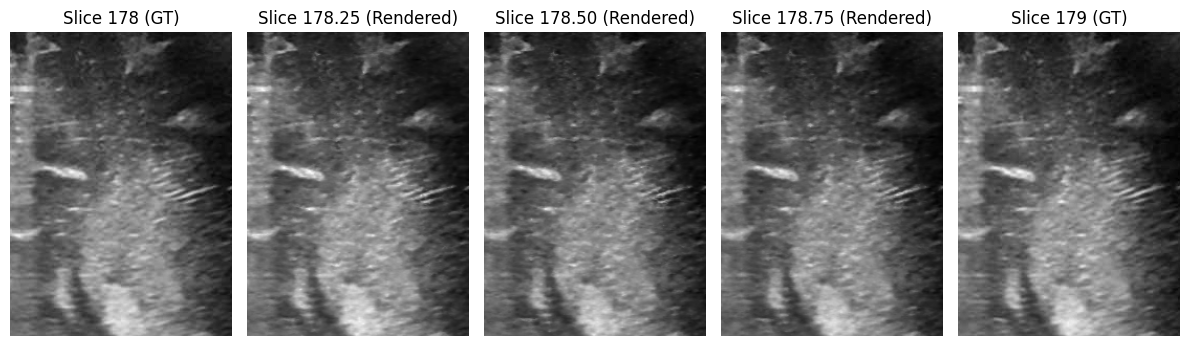


Interpolated images saved to: logs/27-02-2026/HASH_Patient0_0/images/slice_178_179_interpolated_k3.png
  Slice 178.25: range=[12.877985, 115.264313]
  Slice 178.50: range=[14.688365, 121.969612]
  Slice 178.75: range=[15.150087, 120.580597]


In [19]:
# Render k interpolated images uniformly between two slices
import matplotlib.pyplot as plt
import numpy as np

# Input parameters
slice_start_idx = 178  # Starting slice index
slice_end_idx = 179    # Ending slice index
k = 3                 # Number of intermediate images to generate

print(f"Generating {k} uniformly spaced intermediate images between slice {slice_start_idx} and {slice_end_idx}...")

# Get points from start and end slices
points_start = dataset.get_slice_points(slice_start_idx)
points_end = dataset.get_slice_points(slice_end_idx)

# Get viewdirs from start and end slices
viewdirs_start = dataset.get_slice_viewdirs(slice_start_idx)
viewdirs_end = dataset.get_slice_viewdirs(slice_end_idx)

# Generate k uniformly spaced t values between 0 and 1 (excluding endpoints)
t_values = np.linspace(0, 1, k + 2)[1:-1]

print(f"Interpolation t values: {t_values}")

# Render interpolated images
rendered_images = []
height, width = dataset.px_height, dataset.px_width

with torch.no_grad():
    for t in t_values:
        # Interpolate points and viewdirs
        points_interp = (1 - t) * points_start + t * points_end
        viewdirs_interp = (1 - t) * viewdirs_start + t * viewdirs_end
        
        # Normalize points if needed
        if nerf.encoding_type != "HASH" or not nerf.use_encoding:
            point_min = torch.FloatTensor(dataset.point_min).to(device)
            point_max = torch.FloatTensor(dataset.point_max).to(device)
            max_coord = point_max - point_min
            
            points_normalized = torch.add(
                torch.multiply(torch.divide(torch.add(points_interp, -point_min), max_coord), 2), -1)
        else:
            points_normalized = points_interp
        
        # Query the NeRF model
        rendered = nerf.query(points_normalized, viewdirs_interp)
        rendered_reshaped = torch.reshape(rendered, (height, width))
        rendered_images.append(rendered_reshaped)

# Get ground truth for comparison
gt_start = torch.reshape(dataset.get_slice_pixels(slice_start_idx), (height, width))
gt_end = torch.reshape(dataset.get_slice_pixels(slice_end_idx), (height, width))

# Visualize: Start GT + k intermediate rendered + End GT
fig, axes = plt.subplots(1, k + 2, figsize=(4 * (k ), 4))

# Start slice GT
axes[0].imshow(gt_start.cpu().numpy(), cmap='gray')
axes[0].set_title(f'Slice {slice_start_idx} (GT)')
axes[0].axis('off')

# Intermediate rendered images
for i, rendered_img in enumerate(rendered_images):
    t = t_values[i]
    slice_pos = slice_start_idx + t * (slice_end_idx - slice_start_idx)
    axes[i + 1].imshow(rendered_img.cpu().numpy(), cmap='gray')
    axes[i + 1].set_title(f'Slice {slice_pos:.2f} (Rendered)')
    axes[i + 1].axis('off')

# End slice GT
axes[k + 1].imshow(gt_end.cpu().numpy(), cmap='gray')
axes[k + 1].set_title(f'Slice {slice_end_idx} (GT)')
axes[k + 1].axis('off')

plt.tight_layout()
save_path = f'logs/27-02-2026/HASH_Patient0_0/images/slice_{slice_start_idx}_{slice_end_idx}_interpolated_k{k}.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nInterpolated images saved to: {save_path}")
for i, t in enumerate(t_values):
    slice_pos = slice_start_idx + t * (slice_end_idx - slice_start_idx)
    rendered_img = rendered_images[i]
    print(f"  Slice {slice_pos:.2f}: range=[{rendered_img.min():.6f}, {rendered_img.max():.6f}]")


# Crop Image

(np.float64(-0.5), np.float64(943.5), np.float64(707.5), np.float64(-0.5))

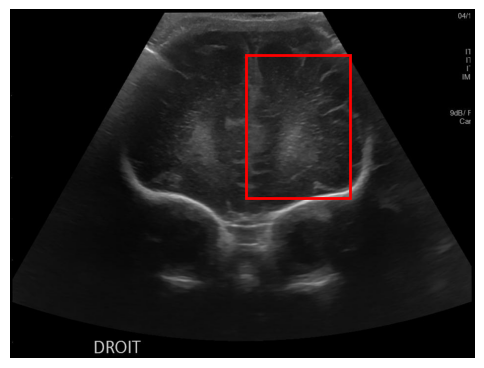

In [21]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

img_path = r"D:\0-Code\NeUF\data\cerebral_data\Pre_traitement_echo_v2\Recalage\Patient0\us_recal_original\us0.jpg"

# Box parameters
x, y, w, h = 478, 93, 212, 290

img = Image.open(img_path).convert("RGB")

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img)
rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
ax.add_patch(rect)
ax.axis('off')



# Visulization MHD direction

In [1]:
from pathlib import Path
import json
import numpy as np

export_dir = Path(r"D:\0-Code\NeUF\exports\full_grid\16-03-2026\ckpt_3")
base_name = "volume_from_npy"

metadata = json.loads((export_dir / "metadata.json").read_text(encoding="utf-8"))
spacing_xyz = tuple(float(v) for v in metadata["spacing_mm_xyz"])

volume_path_candidates = [
    export_dir / "volume.npy",
    export_dir / "volume_zyx.npy",
]
volume_path = next((path for path in volume_path_candidates if path.exists()), None)
if volume_path is None:
    raise FileNotFoundError(f"No volume npy found in {export_dir}")

volume = np.load(volume_path)

if volume_path.name == "volume_zyx.npy":
    # NeUF grid (z, y, x) -> exported MHD array (h, z, w)
    volume = np.transpose(volume, (1, 0, 2))
    volume = np.flip(volume, axis=2)

volume = volume.astype(np.float32, copy=False)
raw_path = export_dir / f"{base_name}.raw"
mhd_path = export_dir / f"{base_name}.mhd"

volume.tofile(raw_path)

# volume is stored as (h, z, w), while MHD header expects (w, z, h)
dim_sizes = (int(volume.shape[2]), int(volume.shape[1]), int(volume.shape[0]))
spacing_sizes = (float(spacing_xyz[1]), float(spacing_xyz[2]), float(spacing_xyz[0]))

header = "\n".join([
    "ObjectType = Image",
    "NDims = 3",
    "BinaryData = True",
    "BinaryDataByteOrderMSB = False",
    "CompressedData = False",
    "TransformMatrix = 1 0 0 0 1 0 0 0 1",
    "Offset = 0 0 0",
    "CenterOfRotation = 0 0 0",
    "AnatomicalOrientation = RAI",
    f"ElementSpacing = {spacing_sizes[0]} {spacing_sizes[1]} {spacing_sizes[2]}",
    f"DimSize = {dim_sizes[0]} {dim_sizes[1]} {dim_sizes[2]}",
    "ElementType = MET_FLOAT",
    f"ElementDataFile = {raw_path.name}",
    "",
])
mhd_path.write_text(header, encoding="ascii")

print(f"Loaded: {volume_path.name}")
print(f"Saved raw: {raw_path}")
print(f"Saved mhd: {mhd_path}")
print(f"Volume shape (h, z, w): {volume.shape}")
print(f"MHD DimSize (w, z, h): {dim_sizes}")
print(f"MHD ElementSpacing: {spacing_sizes}")


Loaded: volume.npy
Saved raw: D:\0-Code\NeUF\exports\full_grid\16-03-2026\ckpt_3\volume_from_npy.raw
Saved mhd: D:\0-Code\NeUF\exports\full_grid\16-03-2026\ckpt_3\volume_from_npy.mhd
Volume shape (h, z, w): (707, 656, 945)
MHD DimSize (w, z, h): (945, 656, 707)
MHD ElementSpacing: (1.0, 1.0, 1.0)


# gCNR

In [3]:
974 - 178



796